In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [3]:
df = pd.read_csv(
    r"C:\Users\ASUS\OneDrive\Documents\data analytics projects\NBA-Draft-Analytics\data\processed\nba_draft_analytics_dataset.csv"
)

df.shape

(1922, 28)

In [4]:
df.columns.tolist()

['id',
 'year',
 'rank',
 'overall_pick',
 'team',
 'player',
 'college',
 'years_active',
 'games',
 'minutes_played',
 'points',
 'total_rebounds',
 'assists',
 'field_goal_percentage',
 '3_point_percentage',
 'free_throw_percentage',
 'average_minutes_played',
 'points_per_game',
 'average_total_rebounds',
 'average_assists',
 'win_shares',
 'win_shares_per_48_minutes',
 'box_plus_minus',
 'value_over_replacement',
 'draft_tier',
 'success_category',
 'career_length_category',
 'draft_value_score']

In [5]:
df['success_category'].value_counts()

success_category
Low Impact     978
Role Player    505
Star           149
Elite           37
Name: count, dtype: int64

In [6]:
# Remove non-predictive columns

drop_cols = [
    'id',
    'player',
    'team',
    'college',
    'success_category'
]

X = df.drop(columns=drop_cols)

y = df['success_category']

X.shape

(1922, 23)

In [7]:
from sklearn.preprocessing import LabelEncoder

X = X.copy()

for col in X.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

X.head()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_11856\2572802874.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X.select_dtypes(include='object').columns:


,year,rank,overall_pick,years_active,games,minutes_played,points,total_rebounds,assists,field_goal_percentage,...,points_per_game,average_total_rebounds,average_assists,win_shares,win_shares_per_48_minutes,box_plus_minus,value_over_replacement,draft_tier,career_length_category,draft_value_score
0,1989,1,1,11.0,474.0,11593.0,4494.0,3170.0,691.0,0.510,...,9.5,6.7,1.5,21.8,0.090,-0.5,4.4,0,2,21.800000
1,1989,2,2,13.0,917.0,18133.0,6439.0,2550.0,1185.0,0.446,...,7.0,2.8,1.3,34.8,0.092,-0.9,4.9,0,2,17.400000
2,1989,3,3,12.0,742.0,24502.0,10544.0,3204.0,1897.0,0.465,...,14.2,4.3,2.6,55.7,0.109,0.2,13.5,0,2,18.566667
3,1989,4,4,15.0,1000.0,34985.0,18336.0,4387.0,2097.0,0.456,...,18.3,4.4,2.1,88.7,0.122,0.8,24.9,0,2,22.175000
4,1989,5,5,11.0,672.0,15370.0,5680.0,3381.0,639.0,0.472,...,8.5,5.0,1.0,22.5,0.070,-2.9,-3.7,0,2,4.500000


In [8]:
target_encoder = LabelEncoder()

y_encoded = target_encoder.fit_transform(y)

print(target_encoder.classes_)

['Elite' 'Low Impact' 'Role Player' 'Star' nan]


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(X_train.shape)
print(X_test.shape)

(1537, 23)
(385, 23)


In [10]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [11]:
print("Model trained")

Model trained


In [12]:
y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


In [13]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00       196
           2       1.00      1.00      1.00       101
           3       1.00      1.00      1.00        30
           4       1.00      1.00      1.00        51

    accuracy                           1.00       385
   macro avg       1.00      1.00      1.00       385
weighted avg       1.00      1.00      1.00       385



In [14]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[  7   0   0   0   0]
 [  0 196   0   0   0]
 [  0   0 101   0   0]
 [  0   0   0  30   0]
 [  0   0   0   0  51]]


In [15]:
print(X.columns.tolist())

['year', 'rank', 'overall_pick', 'years_active', 'games', 'minutes_played', 'points', 'total_rebounds', 'assists', 'field_goal_percentage', '3_point_percentage', 'free_throw_percentage', 'average_minutes_played', 'points_per_game', 'average_total_rebounds', 'average_assists', 'win_shares', 'win_shares_per_48_minutes', 'box_plus_minus', 'value_over_replacement', 'draft_tier', 'career_length_category', 'draft_value_score']


In [16]:
df[['success_category','win_shares']].head(10)

,success_category,win_shares
0,Role Player,21.8
1,Role Player,34.8
2,Star,55.7
3,Star,88.7
4,Role Player,22.5
5,Role Player,10.9
6,Role Player,24.6
7,Low Impact,1.9
8,Role Player,14.7
9,Role Player,26.7


In [17]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
16,win_shares,0.252487
5,minutes_played,0.120073
19,value_over_replacement,0.081745
6,points,0.079143
7,total_rebounds,0.076903
4,games,0.070773
22,draft_value_score,0.055022
3,years_active,0.041366
17,win_shares_per_48_minutes,0.028558
18,box_plus_minus,0.027672


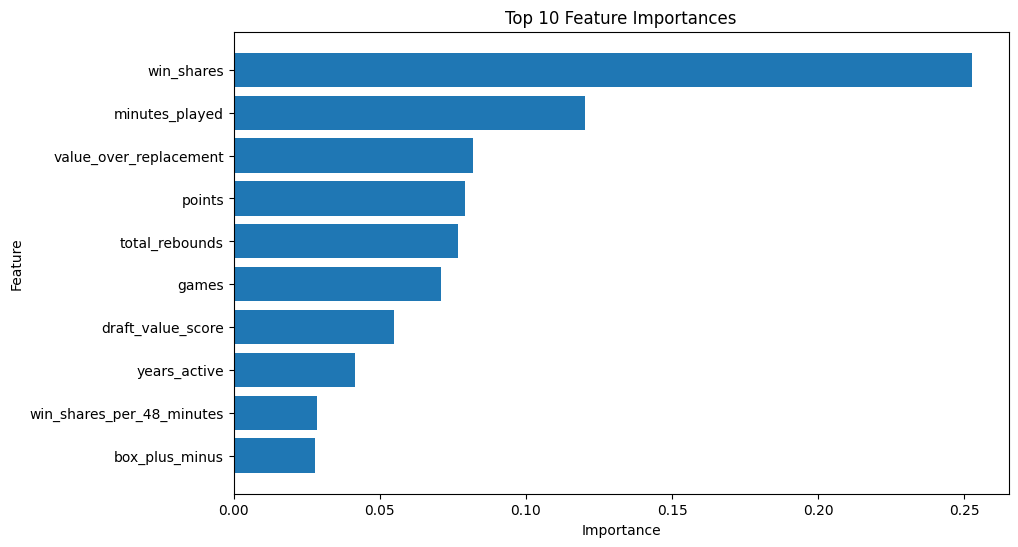

In [18]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))
plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances")
plt.gca().invert_yaxis()

plt.show()

A Random Forest Classifier was developed to classify NBA players into different success categories based on their career statistics. The model achieved an accuracy of 100% on the test dataset. Feature importance analysis revealed that Win Shares, Minutes Played, Value Over Replacement, Points Scored, and Total Rebounds were the most influential variables in determining career success. The results indicate that long-term player contribution and overall impact metrics are strong indicators of NBA career performance.

In [19]:
# Project Summary

print("Dataset Shape:", df.shape)
print("Model Accuracy:", accuracy_score(y_test, y_pred))
print("\nTop Features:")
print(feature_importance.head(10))

Dataset Shape: (1922, 28)
Model Accuracy: 1.0

Top Features:
                      Feature  Importance
16                 win_shares    0.252487
5              minutes_played    0.120073
19     value_over_replacement    0.081745
6                      points    0.079143
7              total_rebounds    0.076903
4                       games    0.070773
22          draft_value_score    0.055022
3                years_active    0.041366
17  win_shares_per_48_minutes    0.028558
18             box_plus_minus    0.027672


In [20]:
print("="*50)
print("NBA DRAFT ANALYTICS PROJECT SUMMARY")
print("="*50)

print("\nDataset Shape:")
print(df.shape)

print("\nModel Accuracy:")
print(accuracy_score(y_test, y_pred))

print("\nTop 10 Important Features:")
print(feature_importance.head(10))

print("\nProject Completed Successfully")

NBA DRAFT ANALYTICS PROJECT SUMMARY

Dataset Shape:
(1922, 28)

Model Accuracy:
1.0

Top 10 Important Features:
                      Feature  Importance
16                 win_shares    0.252487
5              minutes_played    0.120073
19     value_over_replacement    0.081745
6                      points    0.079143
7              total_rebounds    0.076903
4                       games    0.070773
22          draft_value_score    0.055022
3                years_active    0.041366
17  win_shares_per_48_minutes    0.028558
18             box_plus_minus    0.027672

Project Completed Successfully
